In [2]:
from google.colab import files

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

prediction_files = [
    name
    for name in uploaded
    if "prediction" in name.lower()
    and name.lower().endswith(".csv")
]

if len(prediction_files) != 1:
    raise ValueError(
        f"Upload one predictions CSV. Files found: {list(uploaded.keys())}"
    )

prediction_file = prediction_files[0]

predictions_df = pd.read_csv(
    io.BytesIO(uploaded[prediction_file]),
    encoding="utf-8-sig"
)

predictions_df["target_datetime"] = pd.to_datetime(
    predictions_df["target_datetime"]
)

print("Shape:", predictions_df.shape)
print(
    "Test range:",
    predictions_df["target_datetime"].min(),
    "to",
    predictions_df["target_datetime"].max()
)
print("Roads:", predictions_df["street_name"].nunique())

predictions_df.head()

Saving model_comparison_results.csv to model_comparison_results (1).csv
Saving random_forest_test_predictions.csv to random_forest_test_predictions (1).csv
Shape: (960, 5)
Test range: 2024-08-27 00:00:00 to 2024-08-30 23:00:00
Roads: 10


,target_datetime,street_name,target_next_hour,predicted_next_hour,absolute_error
0,2024-08-27 00:00:00,Africa Avenue,9268.0,9706.504540,438.504540
1,2024-08-27 01:00:00,Africa Avenue,6319.0,6579.073255,260.073255
2,2024-08-27 02:00:00,Africa Avenue,3982.0,4756.968996,774.968996
3,2024-08-27 03:00:00,Africa Avenue,3779.0,3987.178108,208.178108
4,2024-08-27 04:00:00,Africa Avenue,4466.0,4242.576331,223.423669


In [3]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

road_results = []

for road_name, road_data in predictions_df.groupby(
    "street_name"
):
    actual = road_data["target_next_hour"]
    predicted = road_data["predicted_next_hour"]

    mae = mean_absolute_error(actual, predicted)

    rmse = mean_squared_error(
        actual,
        predicted
    ) ** 0.5

    r2 = r2_score(actual, predicted)

    actual_total = np.abs(actual).sum()

    wape = (
        np.abs(actual - predicted).sum()
        / actual_total
        * 100
        if actual_total != 0
        else np.nan
    )

    road_results.append({
        "street_name": road_name,
        "records": len(road_data),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE_Percentage": wape,
    })

road_metrics_df = pd.DataFrame(
    road_results
).sort_values("MAE")

road_metrics_df.round(4)

,street_name,records,MAE,RMSE,R2,WAPE_Percentage
0,Africa Avenue,96,2420.2374,3444.4007,0.9590,7.9167
5,Mehrauli Badarpur Road,96,2681.2182,3515.9678,0.9614,7.3772
9,Vikas Marg,96,2704.1027,3476.8285,0.9251,7.4024
6,Noida Link Road,96,2723.4452,3713.1075,0.9457,8.4826
8,Sardar Patel Marg,96,3600.4215,4741.9208,0.9408,7.5504
1,Aurobindo Marg,96,5784.3541,7777.5729,0.9785,5.1916
2,Barapullah Road,96,5934.5472,8393.7606,0.9448,8.6402
4,Mathura Road,96,7379.4361,9489.9597,0.9803,5.1334
7,Outer Ring Road,96,15029.6955,19698.4398,0.9654,6.2984
3,Mahatma Gandhi Marg,96,20892.7793,27767.2176,0.9704,5.5547


In [4]:
road_metrics_df.to_csv(
    "random_forest_per_road_metrics.csv",
    index=False
)

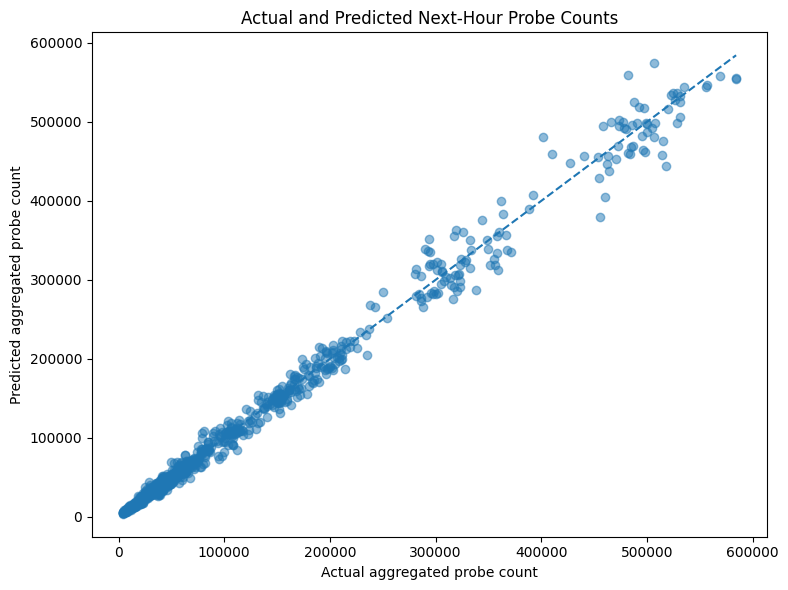

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    predictions_df["target_next_hour"],
    predictions_df["predicted_next_hour"],
    alpha=0.5
)

minimum_value = min(
    predictions_df["target_next_hour"].min(),
    predictions_df["predicted_next_hour"].min()
)

maximum_value = max(
    predictions_df["target_next_hour"].max(),
    predictions_df["predicted_next_hour"].max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(
    "Actual and Predicted Next-Hour Probe Counts"
)
plt.xlabel("Actual aggregated probe count")
plt.ylabel("Predicted aggregated probe count")
plt.tight_layout()

plt.savefig(
    "figure_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

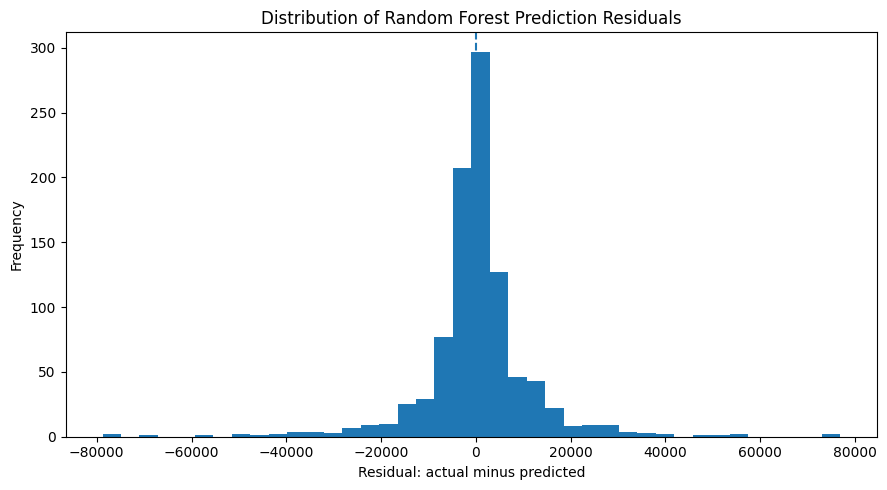

In [6]:
predictions_df["residual"] = (
    predictions_df["target_next_hour"]
    - predictions_df["predicted_next_hour"]
)

plt.figure(figsize=(9, 5))

plt.hist(
    predictions_df["residual"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Random Forest Prediction Residuals"
)
plt.xlabel("Residual: actual minus predicted")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "figure_residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

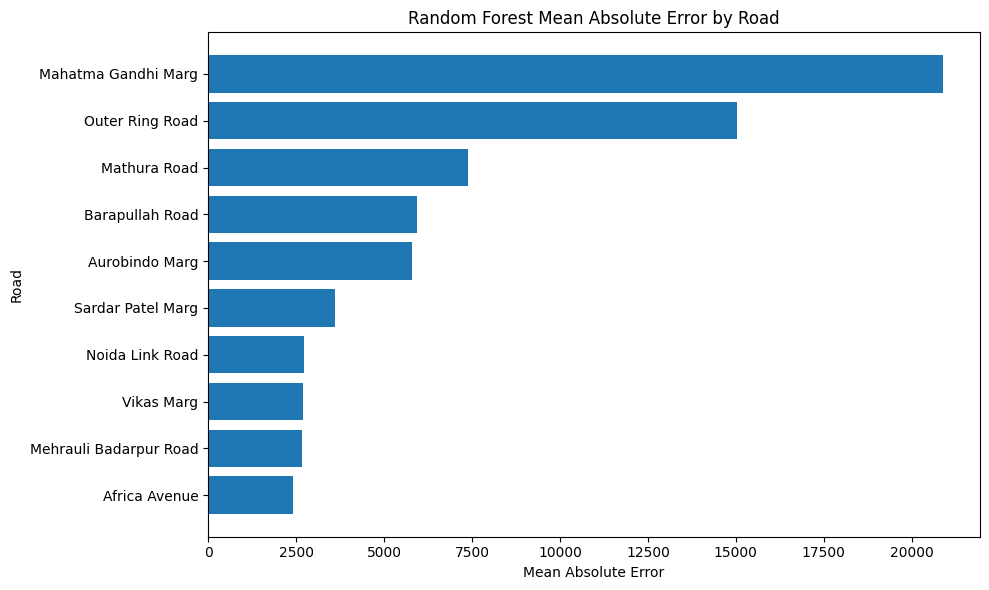

In [7]:
road_error_plot = (
    road_metrics_df
    .sort_values("MAE")
)

plt.figure(figsize=(10, 6))

plt.barh(
    road_error_plot["street_name"],
    road_error_plot["MAE"]
)

plt.title(
    "Random Forest Mean Absolute Error by Road"
)
plt.xlabel("Mean Absolute Error")
plt.ylabel("Road")
plt.tight_layout()

plt.savefig(
    "figure_mae_by_road.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

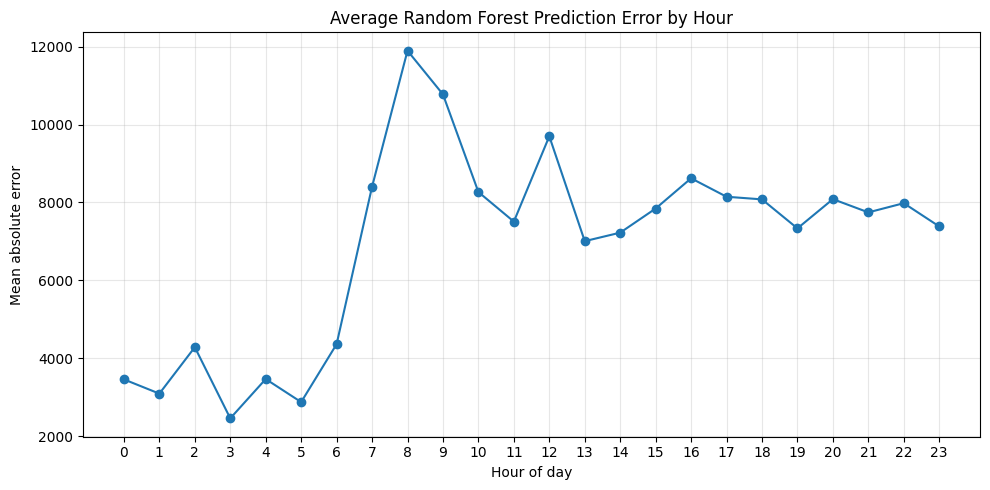

In [8]:
predictions_df["hour"] = (
    predictions_df["target_datetime"].dt.hour
)

hourly_error = (
    predictions_df.groupby("hour")["absolute_error"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_error.index,
    hourly_error.values,
    marker="o"
)

plt.title(
    "Average Random Forest Prediction Error by Hour"
)
plt.xlabel("Hour of day")
plt.ylabel("Mean absolute error")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figure_prediction_error_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()